# Duplicate Videos

This notebook explores how duplicate videos are distributed in the dataset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import pandas as pd

from pathlib import Path

from ssdatam.dataset import DataSet

Define the paths used to access data and metadata.

In [2]:
repo_root = Path.cwd().parent

# data folder
folder_data = repo_root / 'data'

# metadata folder
folder_meta = repo_root / 'metadata'

# mice/recording folders
all_recording_folders = [
    'dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29228-2-10-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29234-6-9-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29712-5-9-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29515-10-12-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29623-4-9-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9628efea20',
]


Initialize a `DataSet` object to handle the full dataset.

In [3]:
# Inizialize and object from DataSet to handle the dataset
ds = DataSet(folder_data, 
             folder_metadata=folder_meta,
             recording=all_recording_folders, 
             check=True,
             verbose=True)

# Load the metadat for all triasls
trials_df = ds.get_trials_metadata()

# Mapping from recording name to rec-animalID-session-scan format
mapping = {}
for rec in ds.recording:
    x = rec.split("-")
    mapping[rec] = f"rec-{ds.info[rec]['animal_id']}-{ds.info[rec]['session']}-{ds.info[rec]['scan_idx']}"


Initializing DataSet -------------------------------------------------------------------------------

Checking the data ----------------------------------------------------------------------------------
 > All data files seem consistent across trials and data types for recording dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce.
 > All data files seem consistent across trials and data types for recording dynamic29228-2-10-Video-8744edeac3b4d1ce16b680916b5267ce.
 > All data files seem consistent across trials and data types for recording dynamic29234-6-9-Video-8744edeac3b4d1ce16b680916b5267ce.
 > All data files seem consistent across trials and data types for recording dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce.
 > All data files seem consistent across trials and data types for recording dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce.
 > All data files seem consistent across trials and data types for recording dynamic29712-5-9-Video-9b4f6a1a067fe51e15306b9

## Duplicates across recordings

Check whether videos are repeated across different recordings.

Videos appearing in more than 1 unique recording: 1895 out of 1987 unique videos
Videos appearing in 1 unique recording: 92 out of 1987 unique videos


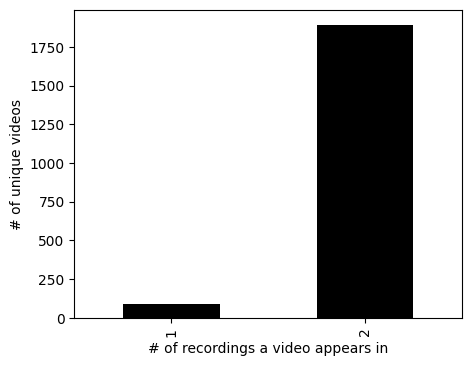

In [5]:
n_unique_videos = trials_df['video_ID'].nunique()

# Find the videos repeated across recordings
counts = ds.count_videos_across(['recording','label','video_ID'])

# Find IDs that have more than 1 unique recording
count_recordings_x_videoid = counts.groupby('video_ID')['recording'].nunique()
ids_with_diff_recordings = count_recordings_x_videoid[count_recordings_x_videoid > 1].index
print(f"Videos appearing in more than 1 unique recording: {len(ids_with_diff_recordings.to_list())} out of {n_unique_videos} unique videos")
print(f"Videos appearing in 1 unique recording: {n_unique_videos - len(ids_with_diff_recordings.to_list())} out of {n_unique_videos} unique videos")

# Plot an histogram with the number of unique videos appearing in n recordings
fig, ax = plt.subplots(figsize=(5, 4))
count_recordings_x_videoid.value_counts().sort_index().plot(kind='bar', ax=ax, color='black')
ax.set_xlabel("# of recordings a video appears in")
ax.set_ylabel("# of unique videos")
fig.savefig(Path(repo_root, 'figures', f'count-video-duplicates_n-recordings.png'))

### Videos appearing in 1 or 2 recordings

Find the pairs of recording with same videos presentted

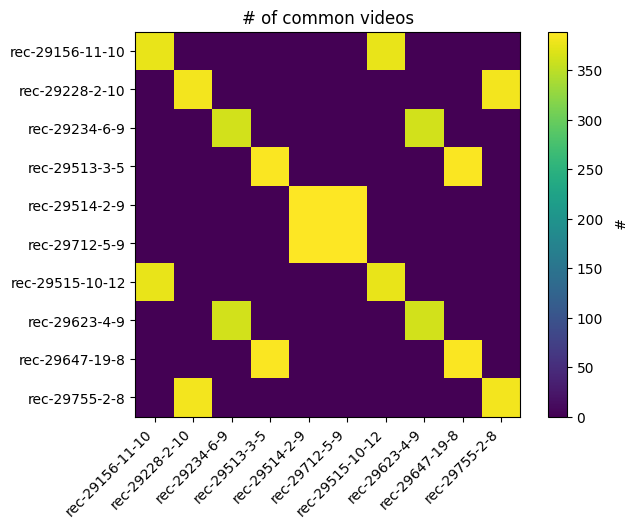

In [6]:
ordered_labels = ['NaturalVideo','NaturalImages','GaussianDot','Gabor','PinkNoise','RandomDots']

# Find the videos IDs that appear in 2 unique recording and count the number of unique videos appearing in each recording among those
ids_2_recordings = count_recordings_x_videoid[count_recordings_x_videoid == 2].index
trials_df_2_recording = trials_df[trials_df['video_ID'].isin(ids_2_recordings)]

matrix = np.zeros((len(ds.recording), len(ds.recording)), dtype=int)
for i, rec1 in enumerate(ds.recording):
    for j, rec2 in enumerate(ds.recording):
        ids_rec1 = set(trials_df_2_recording[trials_df_2_recording['recording'] == rec1]['video_ID'])
        ids_rec2 = set(trials_df_2_recording[trials_df_2_recording['recording'] == rec2]['video_ID'])
        common_ids = ids_rec1.intersection(ids_rec2)
        matrix[i, j] = len(common_ids)

matrix_common_videos = matrix
# plot the matrix
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(matrix, cmap='viridis', aspect='equal')
ax.set_aspect('equal', adjustable='box')
ax.set_xticks(np.arange(len(ds.recording)))
ax.set_yticks(np.arange(len(ds.recording)))
ax.set_xticklabels([mapping[rec] for rec in ds.recording], rotation=45, ha='right')
ax.set_yticklabels([mapping[rec] for rec in ds.recording])
ax.set_title(f"# of common videos")
bcol = fig.colorbar(im, ax=ax)
bcol.set_label("#", rotation=270, labelpad=15)
fig.savefig(Path(repo_root, 'figures', f'count-video-duplicates_in-2-recordings_n-common-videos-by-recording.png'))
    
    

Find recordings sharing common videos

In [7]:
pair_recordings = []
for i, rec1 in enumerate(ds.recording):
    idx = set(np.where(matrix_common_videos[i,:]>0)[0])
    idx.discard(i) # remove self
    if len(idx)>0:
        new_set = set([rec1]+[ds.recording[j] for j in idx])
        if new_set not in pair_recordings:
            pair_recordings.append(new_set)
        
print(f"Number of pairs of recordings sharing at least 1 video: {len(pair_recordings)}")
pair_recordings

Number of pairs of recordings sharing at least 1 video: 5


[{'dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce',
  'dynamic29515-10-12-Video-9b4f6a1a067fe51e15306b9628efea20'},
 {'dynamic29228-2-10-Video-8744edeac3b4d1ce16b680916b5267ce',
  'dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9628efea20'},
 {'dynamic29234-6-9-Video-8744edeac3b4d1ce16b680916b5267ce',
  'dynamic29623-4-9-Video-9b4f6a1a067fe51e15306b9628efea20'},
 {'dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce',
  'dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20'},
 {'dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce',
  'dynamic29712-5-9-Video-9b4f6a1a067fe51e15306b9628efea20'}]

Plot for the videos appearing in 2 recording, 
- how they are distributed across recordings
- how they are distributed across labels

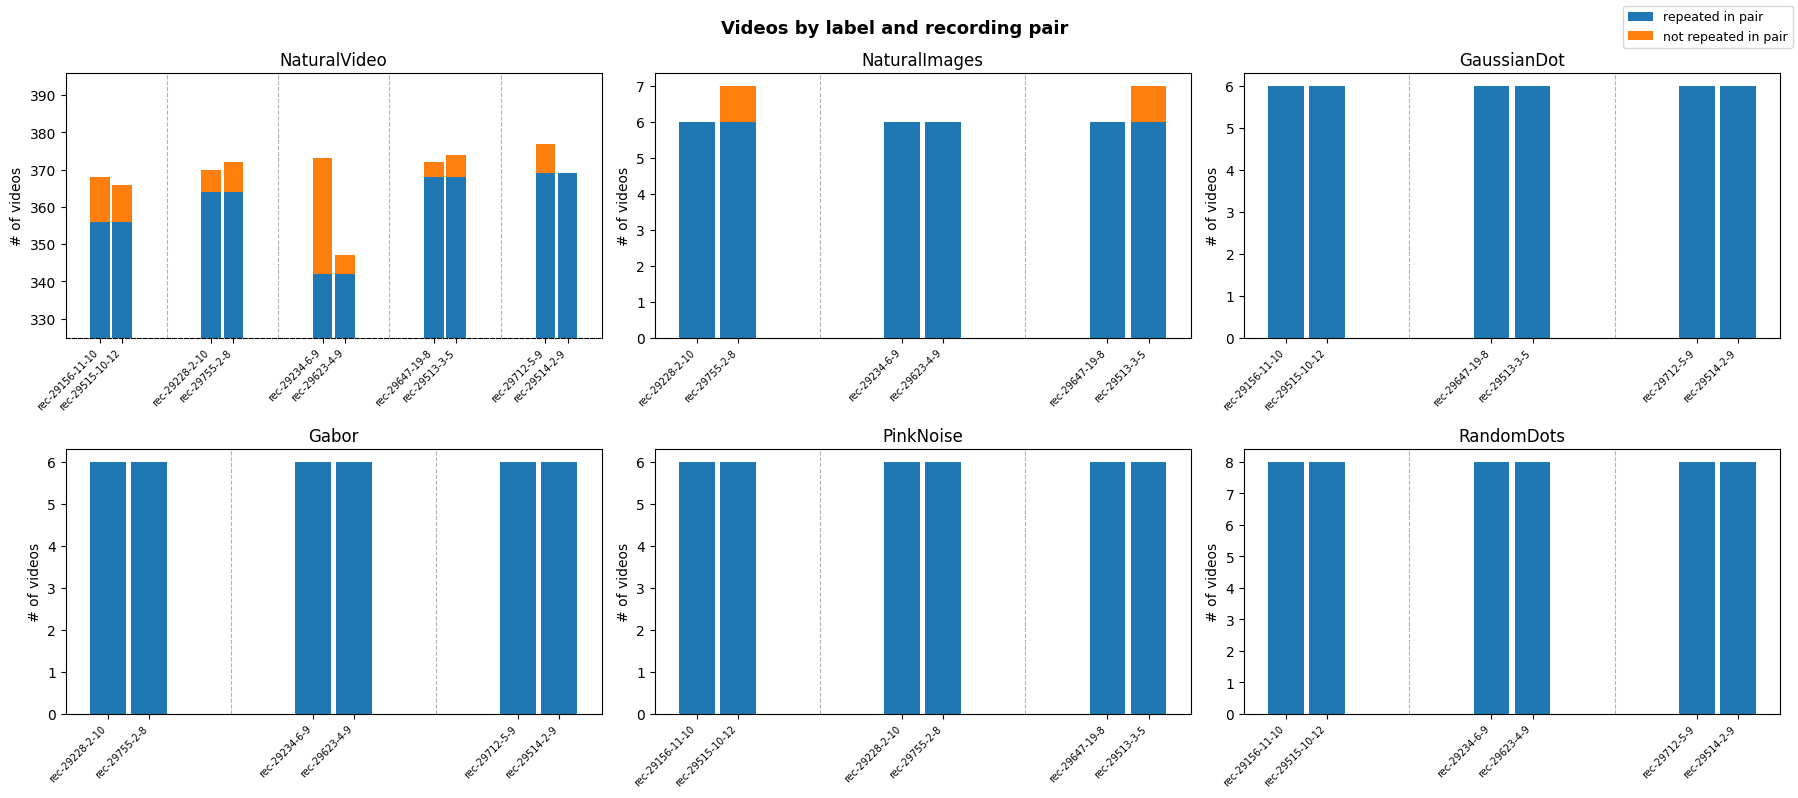

In [9]:

color_repeated = '#1f77b4'
color_not_repeated = '#ff7f0e'
bar_width = 0.35
rec_gap = 0.05       # gap between the two bars within a pair
pair_gap = 1.2       # gap between pairs

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey=False)
axes = axes.flatten()

for ax_idx, lab in enumerate(ordered_labels):
    ax = axes[ax_idx]

    # find pairs that share at least one video of this label
    lab_pairs = []
    for pair in pair_recordings:
        pair_list = list(pair)
        ids_shared = set()
        for i, rec1 in enumerate(pair_list):
            for rec2 in pair_list[i+1:]:
                ids1 = set(trials_df[(trials_df['recording'] == rec1) & (trials_df['label'] == lab)]['video_ID'])
                ids2 = set(trials_df[(trials_df['recording'] == rec2) & (trials_df['label'] == lab)]['video_ID'])
                ids_shared |= ids1 & ids2
        if len(ids_shared) > 0:
            lab_pairs.append(pair_list)

    bar_positions = []   # (pair_list, rec, x_pos)
    level1_ticks, level1_labels = [], []
    level2_centers = []

    cursor = 0.0
    for p_idx, pair_list in enumerate(lab_pairs):
        group_xs = []
        for r_idx, rec in enumerate(pair_list):
            pos = cursor + r_idx * (bar_width + rec_gap)
            bar_positions.append((pair_list, rec, pos))
            level1_ticks.append(pos)
            level1_labels.append(mapping[rec])
            group_xs.append(pos)
        level2_centers.append(float(np.mean(group_xs)))
        cursor += len(pair_list) * (bar_width + rec_gap) + pair_gap

    all_n_rep = []
    bar_data = []
    for pair_list, rec, pos in bar_positions:
        ids_this = set(trials_df[(trials_df['recording'] == rec) & (trials_df['label'] == lab)]['video_ID'])
        ids_others = set().union(*[
            set(trials_df[(trials_df['recording'] == r) & (trials_df['label'] == lab)]['video_ID'])
            for r in pair_list if r != rec
        ])
        shared = ids_this & ids_others
        n_rep = len(shared)
        n_not = len(ids_this - shared)
        bar_data.append((pos, n_rep, n_not))
        all_n_rep.append(n_rep)

    # repeated at bottom, not_repeated on top
    for pos, n_rep, n_not in bar_data:
        ax.bar(pos, n_rep, width=bar_width, color=color_repeated)
        ax.bar(pos, n_not, width=bar_width, bottom=n_rep, color=color_not_repeated)

    # for NaturalVideo zoom in by starting y-axis near the min repeated value
    if all_n_rep:
        y_max = max(n_rep + n_not for _, n_rep, n_not in bar_data) * 1.05
        if lab == 'NaturalVideo':
            y_min = max(0, min(all_n_rep) * 0.95)
            ax.spines['bottom'].set_linestyle('--')  # indicate broken axis
        else:
            y_min = 0
        ax.set_ylim(y_min, y_max)

    ax.set_xticks(level1_ticks)
    ax.set_xticklabels(level1_labels, rotation=45, ha='right', fontsize=7)

    # separators between pairs
    for p_idx in range(len(lab_pairs) - 1):
        sep = level2_centers[p_idx] + (level2_centers[p_idx + 1] - level2_centers[p_idx]) / 2
        ax.axvline(sep, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

    ax.set_title(lab)
    ax.set_ylabel("# of videos")

legend_elements = [
    Patch(facecolor=color_repeated, label='repeated in pair'),
    Patch(facecolor=color_not_repeated, label='not repeated in pair'),
]
fig.legend(handles=legend_elements, loc='upper right', fontsize=9)
fig.suptitle("Videos by label and recording pair", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
fig.savefig(Path(repo_root, 'figures', f'video-duplicates_by-recording-pair_by-label.png'))



Print the two videos belonging to NatutalImages and appearing in only one recording

They correspond to the videos with bad properties

In [11]:
# Find the videos IDs that appear in only 1 unique recording and count the number of unique videos appearing in each recording among those
ids_1_recordings = count_recordings_x_videoid[count_recordings_x_videoid == 1].index
trials_df_1_recording = trials_df[trials_df['video_ID'].isin(ids_1_recordings)]

trials_df_1_recording[trials_df_1_recording['label'] == 'NaturalImages']

,recording,label,video_ID,trial,trial_type,valid_frames,valid_trial,valid_frames_video,valid_frames_response,valid_response
2592,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v583546,668,live_test_bonus,403,False,403,403,True
6591,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v885749,156,live_test_bonus,414,False,414,414,False


## Replicates within recordings

Count the number of replicates per video within each label.


Recording: rec-29156-11-10 ============================================

Label: NaturalVideo
- 350 videos, 1 times
- 12 videos, 10 times
- 5 videos, 9 times
- 1 videos, 8 times

Label: GaussianDot
- 5 videos, 10 times
- 1 videos, 9 times

Label: PinkNoise
- 5 videos, 10 times
- 1 videos, 9 times

Label: RandomDots
- 7 videos, 10 times
- 1 videos, 9 times

Recording: rec-29228-2-10 ============================================

Label: NaturalVideo
- 352 videos, 1 times
- 14 videos, 10 times
- 3 videos, 9 times
- 1 videos, 8 times

Label: NaturalImages
- 5 videos, 10 times
- 1 videos, 9 times

Label: Gabor
- 5 videos, 10 times
- 1 videos, 9 times

Label: PinkNoise
- 5 videos, 10 times
- 1 videos, 9 times

Recording: rec-29234-6-9 ============================================

Label: NaturalVideo
- 355 videos, 1 times
- 13 videos, 10 times
- 5 videos, 9 times

Label: NaturalImages
- 6 videos, 10 times

Label: Gabor
- 5 videos, 10 times
- 1 videos, 9 times

Label: RandomDots
- 8 videos, 10 

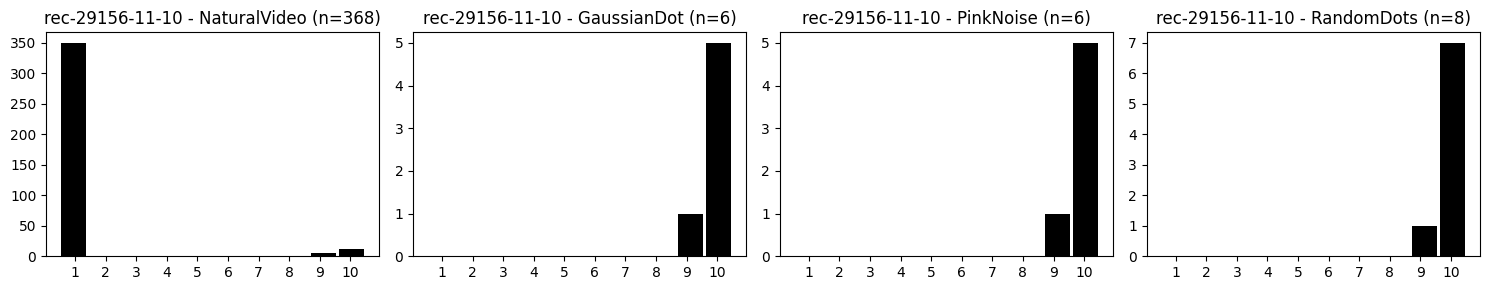

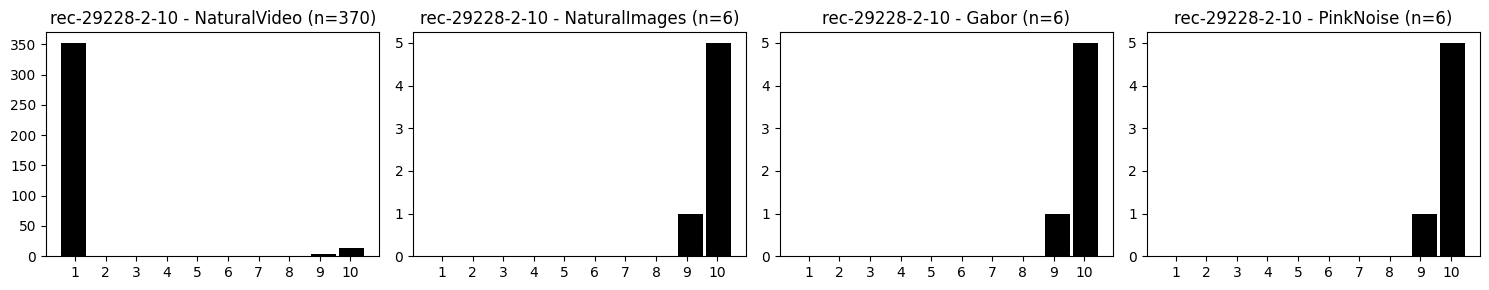

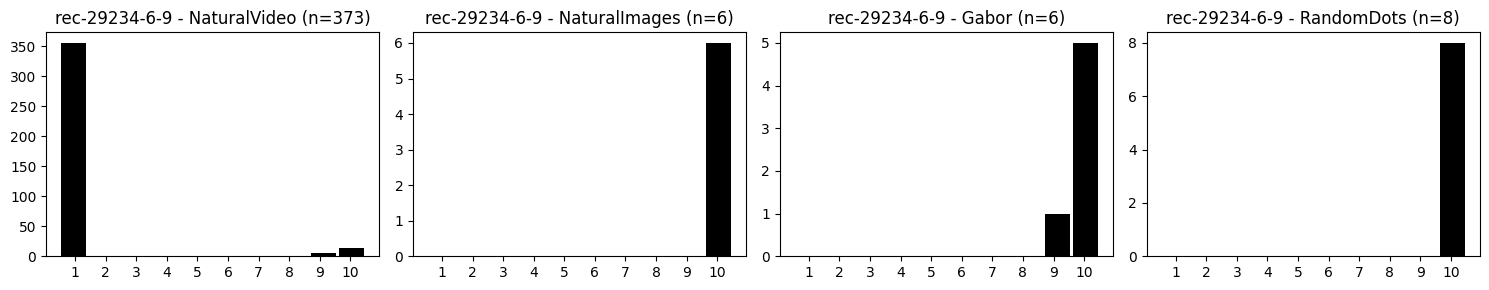

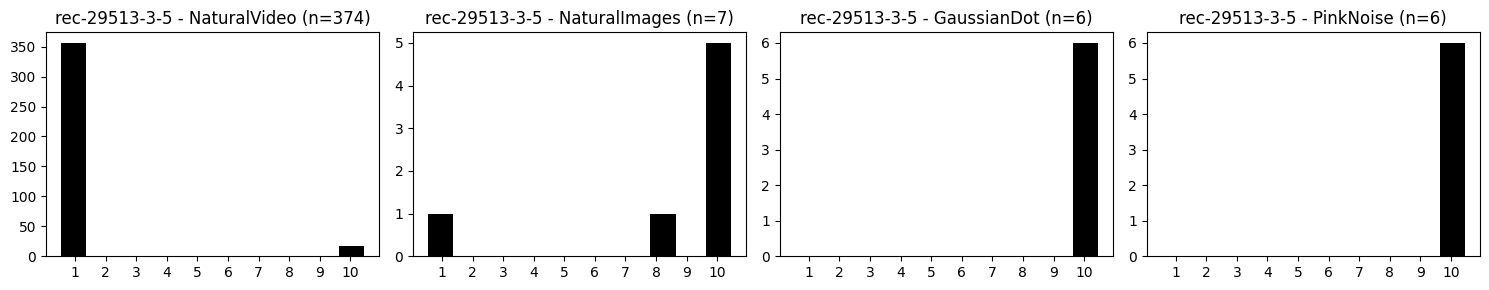

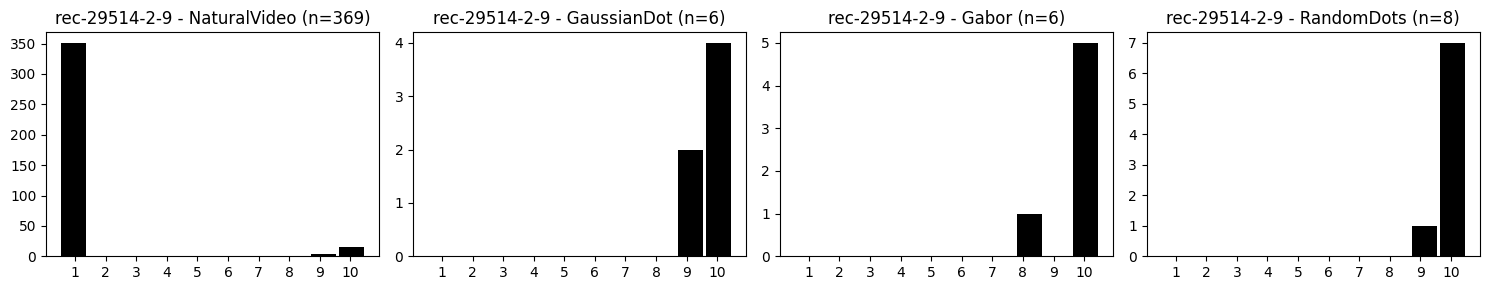

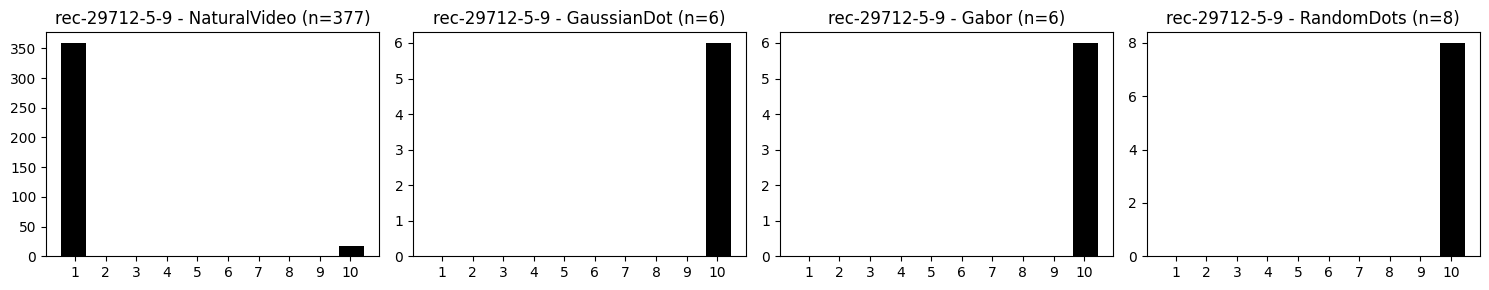

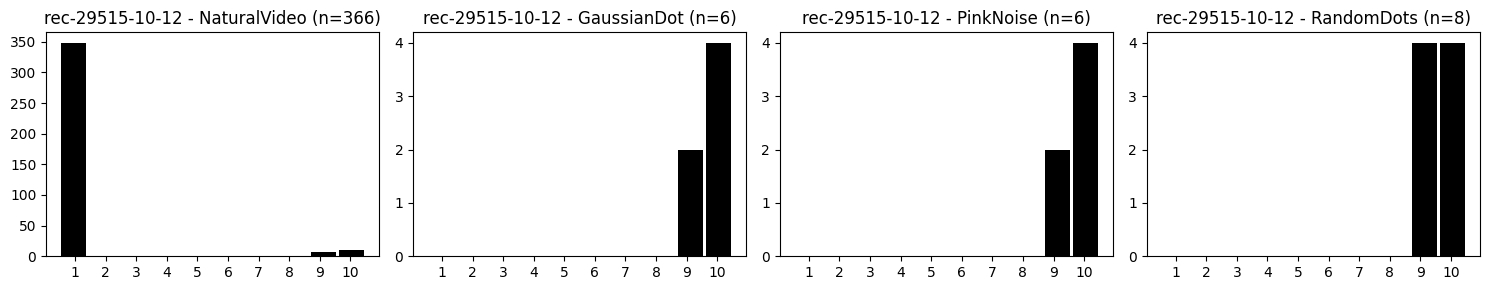

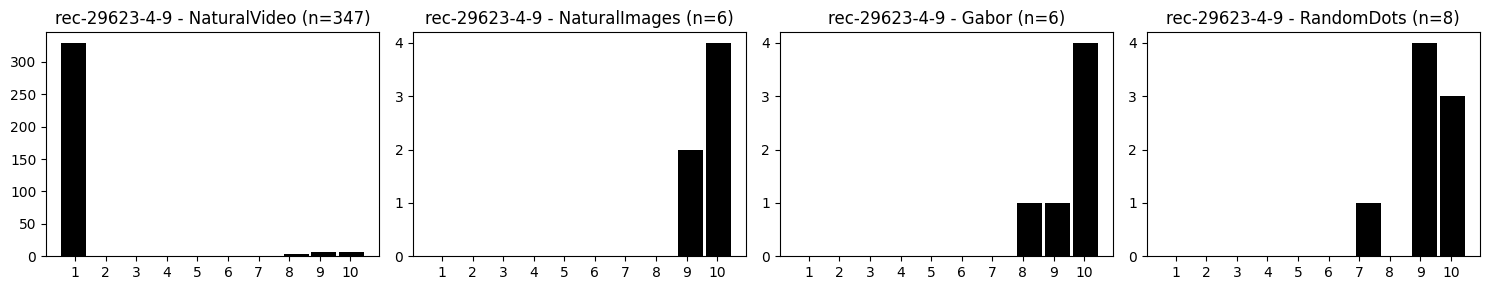

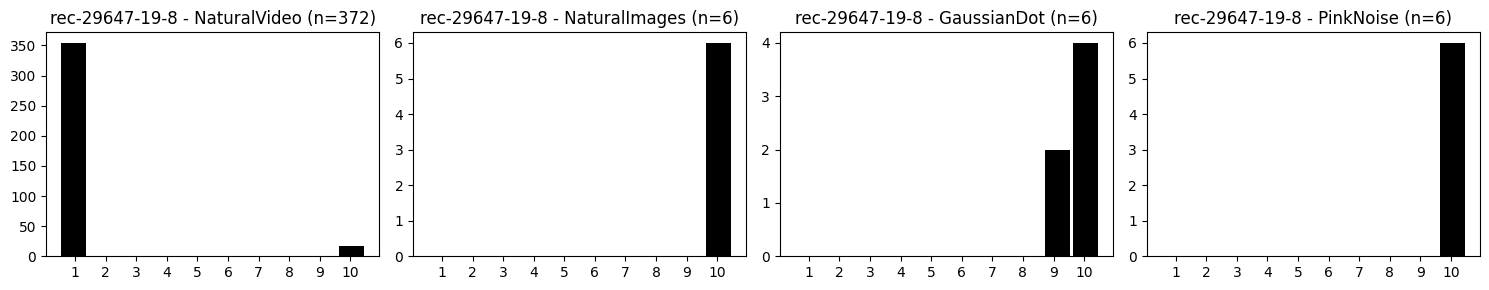

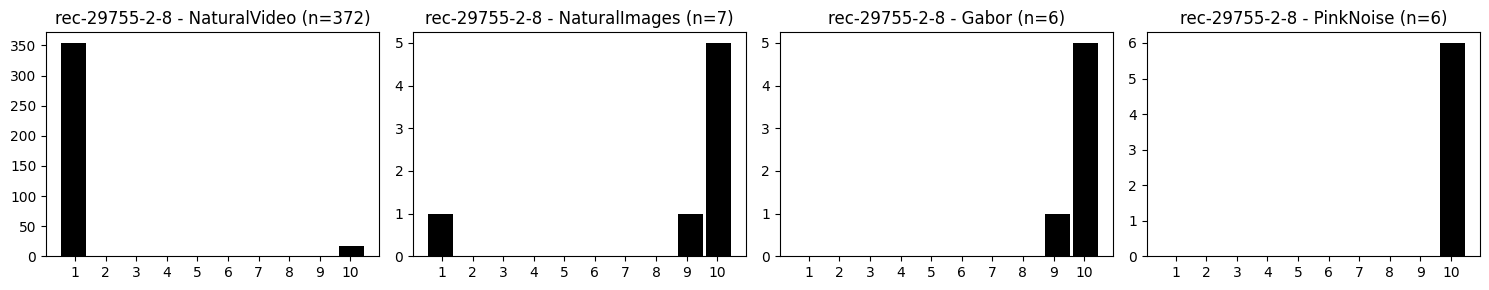

In [12]:
ordered_labels = ['NaturalVideo','NaturalImages','GaussianDot','Gabor','PinkNoise','RandomDots']

# for each recording and label find the number of replicates of each video
counts = ds.count_videos_across(['recording','label','video_ID'])
results = counts.value_counts(["count", "recording", "label"]).reset_index(name="n_videos")

for rec in ds.recording:
    all_trials_df_rec = ds.filter_trials(recording=rec)
    labels = set(all_trials_df_rec['label'].to_list())
    labels = [x for x in ordered_labels if x in labels]
    print(f"\nRecording: {mapping[rec]} ============================================")
        
    fig, ax =plt.subplots(nrows=1, ncols=4, figsize=(15, 3))
    for i, label in enumerate(labels):
        counts_rec_lab = counts[(counts['recording']==rec) & (counts['label']==label)]
        results_rec_lab = results[(results['recording']==rec) & (results['label']==label)]
        print(f"\nLabel: {label}")
        for iter, row in results_rec_lab.iterrows():
            print(f"- {row['n_videos']} videos, {row['count']} times")
        
        d = counts_rec_lab['count'].to_numpy()
        h = ax[i].hist(d, range=(.5, 10.5), bins=11, color='k',rwidth=0.9)
        ax[i].set_xticks(np.arange(1,11))
        ax[i].set_title(f"{mapping[rec]} - {label} (n={len(d)})")

    fig.tight_layout()
    fig.savefig(Path(repo_root, 'figures', f'count-video-duplicates_x-label_{mapping[rec]}.png'))

### Inspect recordings with unusual number of appearances of videos

#### Recording ...29513-3-5... for NaturalImages

In recording ...29513-3-5..., one NaturalImages video appears only once.

Print repetition counts for videos classified as NaturalImages in recording ...3-5....

In [13]:
rec = 'dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce'
label = "NaturalImages"
counts[(counts['recording']==rec) & (counts['label']==label)]

,recording,label,video_ID,count
97,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v090089,10
99,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v969497,10
102,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v065428,10
111,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v139482,10
112,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v098651,10
363,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v582341,8
1650,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v583546,1


Print a DataFrame with trials for the video ID that appears 8 times.

In [14]:
ds.filter_trials(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', label="NaturalImages", video_ID='v582341')

,recording,label,video_ID,trial,trial_type,valid_frames,valid_trial,valid_frames_video,valid_frames_response,valid_response
2160,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v582341,685,live_test_bonus,306,True,306,306,True
2249,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v582341,693,live_test_bonus,306,True,306,306,True
2391,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v582341,705,live_test_bonus,306,True,306,306,True
2519,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v582341,702,live_test_bonus,305,True,305,305,True
2537,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v582341,681,live_test_bonus,305,True,305,305,True
2659,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v582341,689,live_test_bonus,305,True,305,305,True
2793,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v582341,719,live_test_bonus,305,True,305,305,True
2852,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v582341,717,live_test_bonus,305,True,305,305,True


Print a DataFrame with trials for the video ID that appears only once.

In [15]:
ds.filter_trials(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', label="NaturalImages", video_ID='v583546')

,recording,label,video_ID,trial,trial_type,valid_frames,valid_trial,valid_frames_video,valid_frames_response,valid_response
2592,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v583546,668,live_test_bonus,403,False,403,403,True


The video that appears once is labeled as an invalid trial; it corresponds to the video with bad segments.

Load the video that appears 8 times and the one that appears once (the invalid trial).

For both videos, plot frame-to-frame changes and display sample frames.

Warning. load_metadata: 'valid_frames' mismatch between object and metadata file.


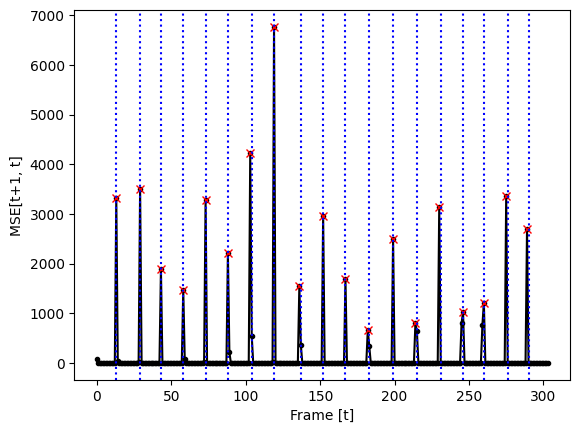

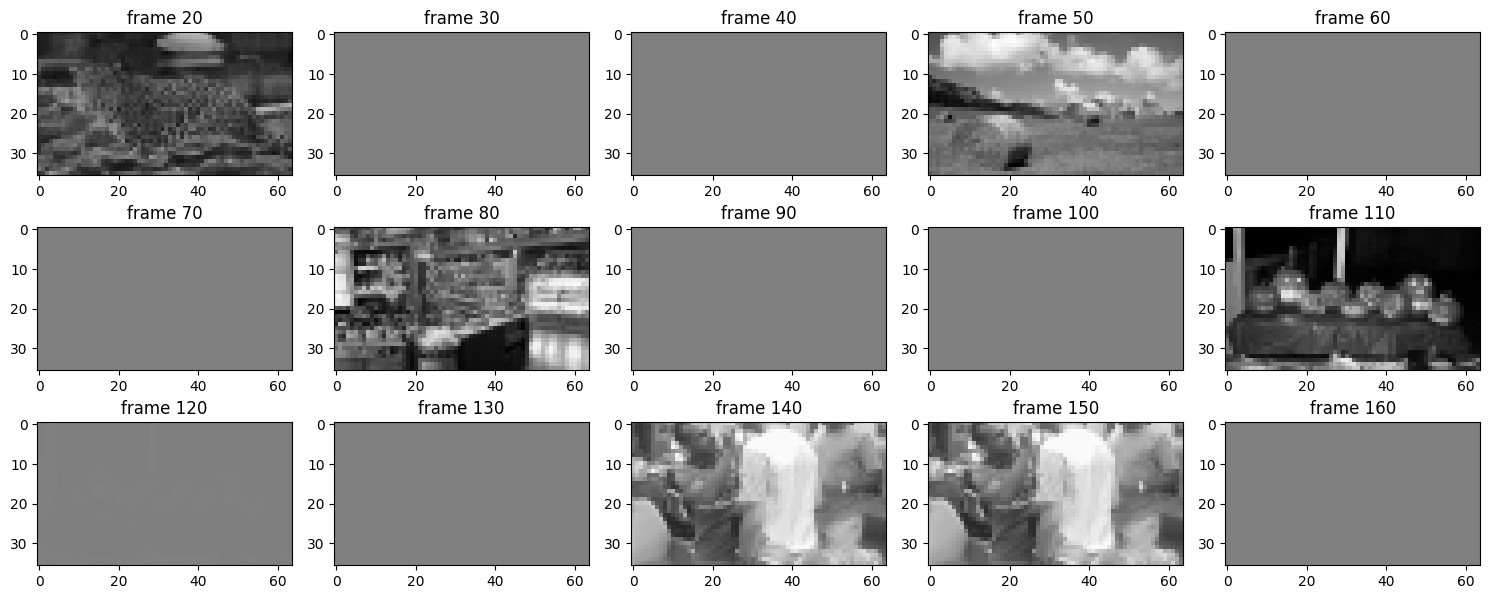

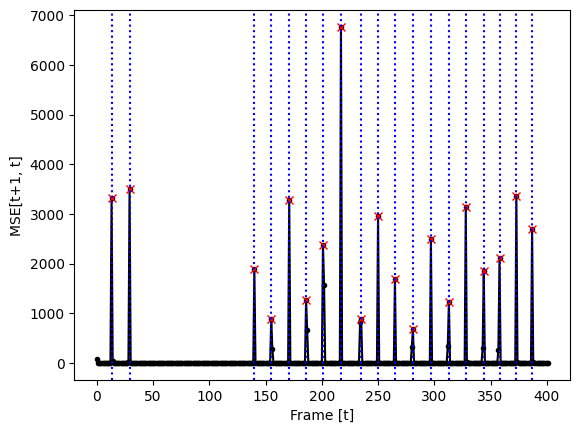

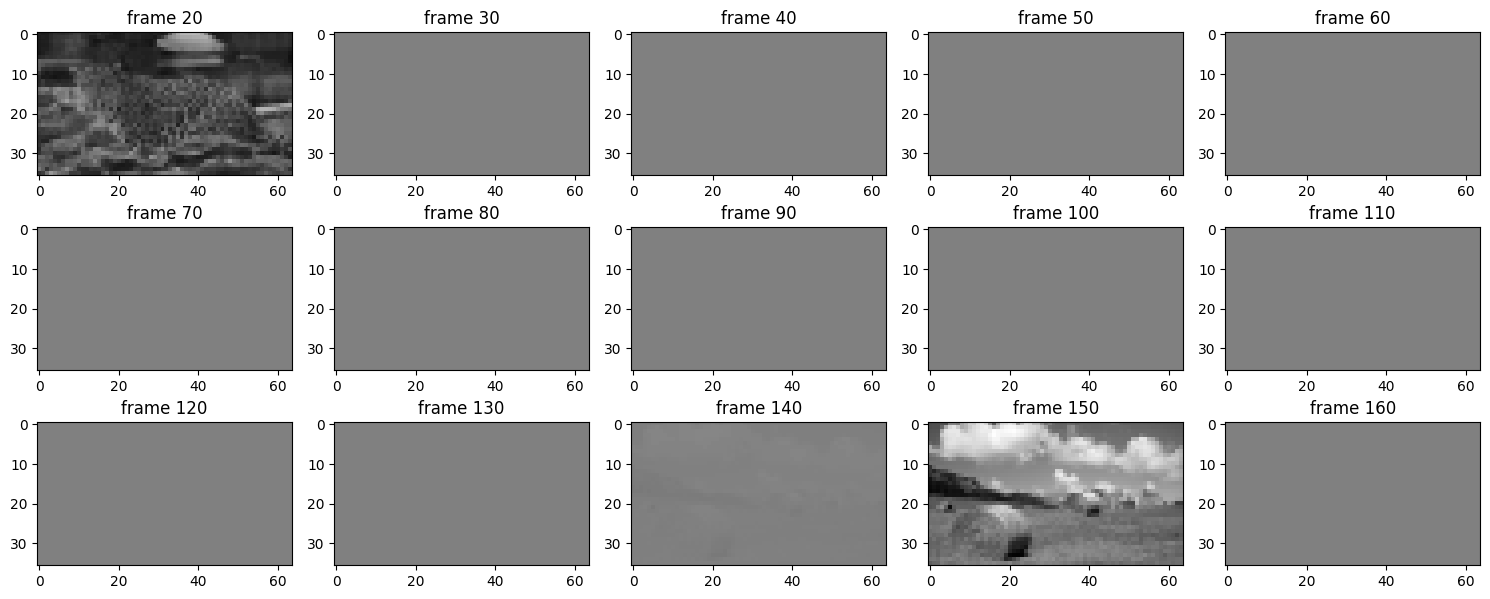

In [16]:
# load
video_i = ds.load_video_by_trial(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', trial='702')
video_j = ds.load_video_by_trial(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', trial='668')
# plot
frames = np.arange(20,170,10)
_ = video_i.plot_changes()
_ = video_i.plot_frames(frames)
_ = video_j.plot_changes()
_ = video_j.plot_frames(frames)

#### Recording 29755-2-8 for NaturalImages

In recording 29755-2-8, one NaturalImages video appears only once.

Print repetition counts for videos classified as NaturalImages in recording ...3-5....

In [17]:
rec = 'dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9628efea20'
label = "NaturalImages"
counts[(counts['recording']==rec) & (counts['label']==label)]

,recording,label,video_ID,count
273,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v609482,10
280,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v585224,10
282,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v823580,10
289,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v914100,10
296,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v629507,10
359,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v043192,9
3605,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v885749,1


Print a DataFrame with trials for the video ID that appears 9 times.

In [18]:
ds.filter_trials(recording='dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9628efea20', label="NaturalImages", video_ID='v043192')

,recording,label,video_ID,trial,trial_type,valid_frames,valid_trial,valid_frames_video,valid_frames_response,valid_response
6503,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v043192,363,live_test_bonus,319,True,319,414,False
6519,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v043192,173,live_test_bonus,319,True,319,414,False
6625,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v043192,52,live_test_bonus,319,True,319,414,False
6678,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v043192,603,live_test_bonus,319,True,319,414,False
6784,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v043192,607,live_test_bonus,319,True,319,414,False
6790,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v043192,250,live_test_bonus,319,True,319,414,False
6923,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v043192,323,live_test_bonus,319,True,319,414,False
7041,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v043192,561,live_test_bonus,319,True,319,414,False
7127,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v043192,35,live_test_bonus,319,True,319,414,False


Print a DataFrame with trials for the video ID that appears only once.

In [19]:
ds.filter_trials(recording='dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9628efea20', label="NaturalImages", video_ID='v885749')

,recording,label,video_ID,trial,trial_type,valid_frames,valid_trial,valid_frames_video,valid_frames_response,valid_response
6591,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalImages,v885749,156,live_test_bonus,414,False,414,414,False


The video that appears once is labeled as an invalid trial; it corresponds to the video with bad segments.

Load the video that appears 9 times and the one that appears once (the invalid trial).

For both videos, plot frame-to-frame changes and display sample frames.

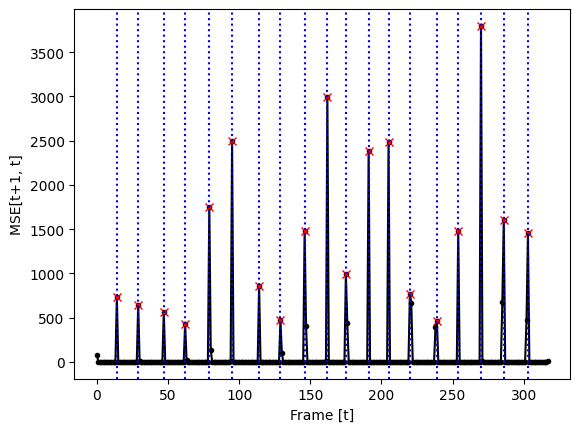

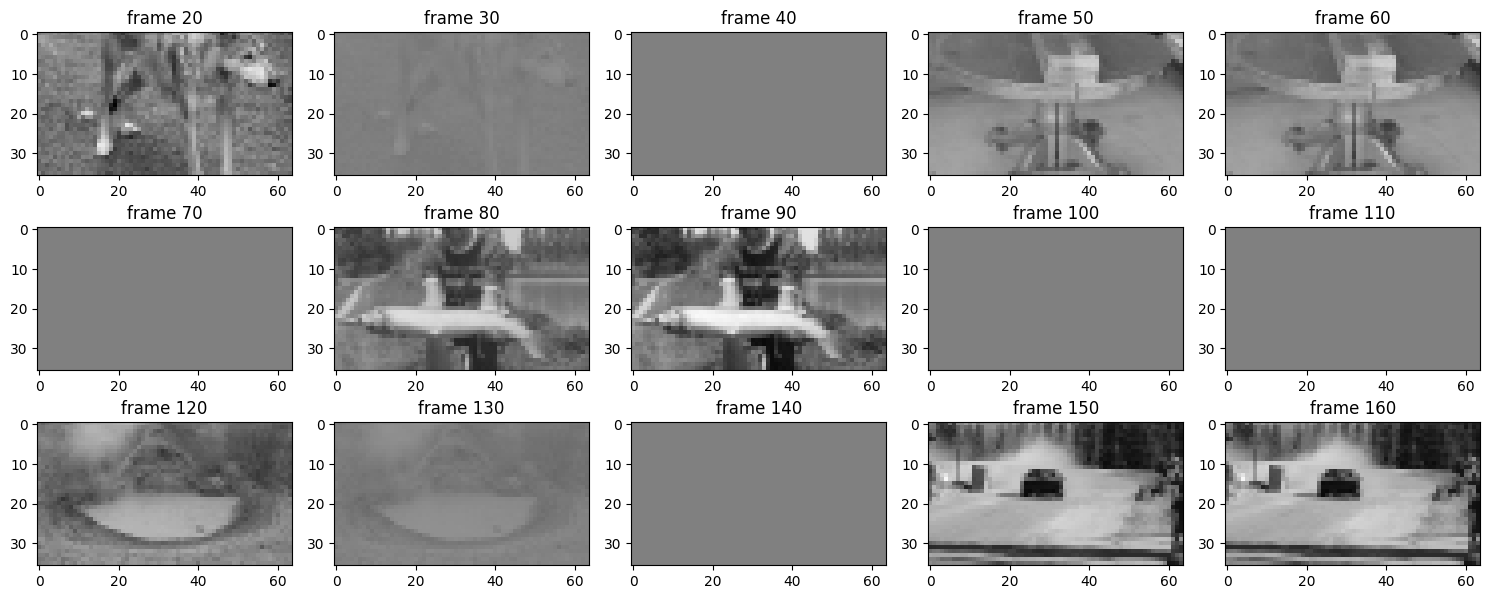

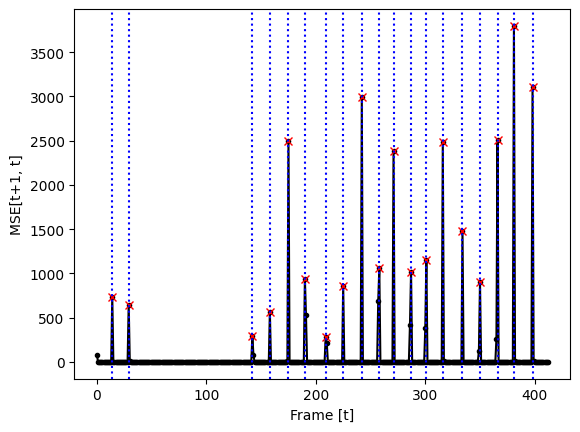

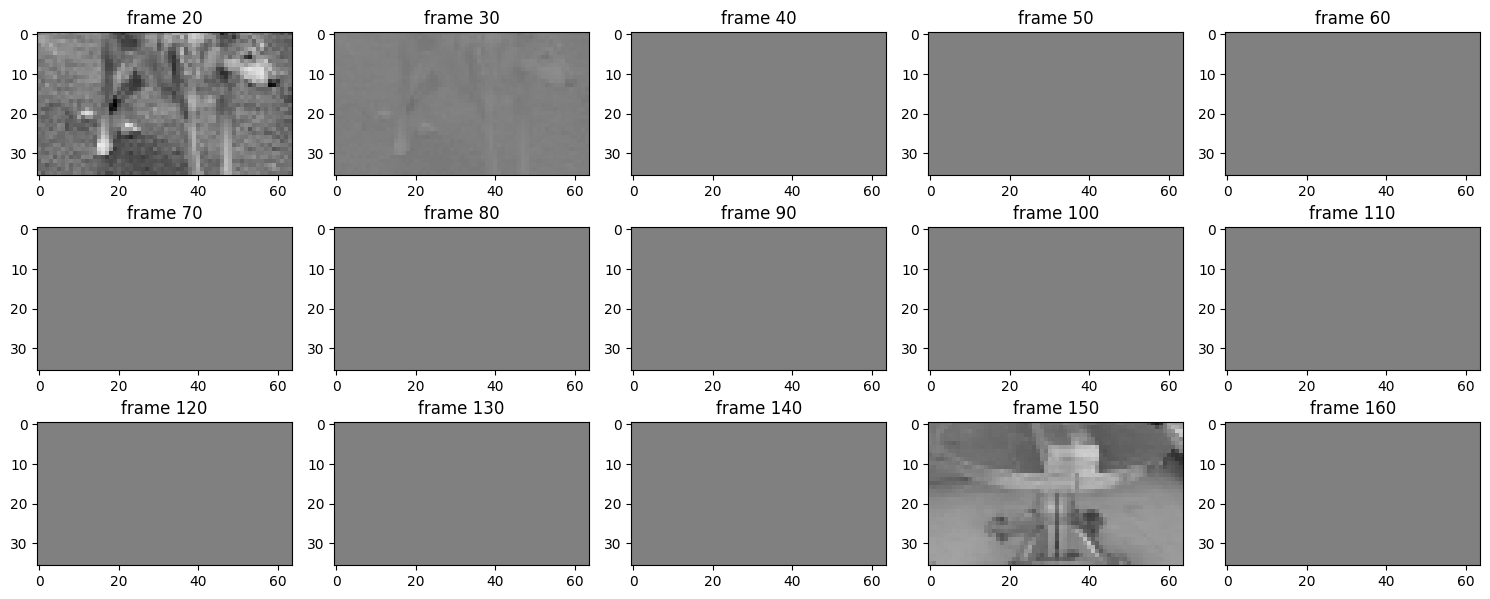

In [20]:
# load
video_i = ds.load_video_by_trial(recording='dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9628efea20', trial='363')
video_j = ds.load_video_by_trial(recording='dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9628efea20', trial='156')
# plot
frames = np.arange(20, 170, 10)
_ = video_i.plot_changes()
_ = video_i.plot_frames(frames)
_ = video_j.plot_changes()
_ = video_j.plot_frames(frames)

## Video similarity

Check the distribution of dissimilarity values across labels (for one recording).

In [20]:
def plot_dissimilarity_matrix(dissimilarity):
    fig, ax =plt.subplots(nrows=1, ncols=1, figsize=(6, 6))
    vmax = np.max(dissimilarity[np.isnan(dissimilarity)==False].flatten())
    im_diss = ax.imshow(dissimilarity, cmap='Reds_r', vmin=0, vmax=vmax, aspect='equal')
    ax.set_aspect('equal', adjustable='box')
    bcol = fig.colorbar(im_diss, ax=ax)
    bcol.set_label("dissimilarity", rotation=270, labelpad=15)
    ax.set_xlabel("video index")
    ax.set_ylabel("video index")
    return fig, ax

In [21]:
def plot_dissimilarity_hist(dissimilarity,bins=100, range=None):
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 6))
    if range is None:
        range = (0, np.max(dissimilarity[np.isnan(dissimilarity)==False].flatten()))
    h = ax.hist(dissimilarity.flatten(), range=range, bins=bins, color='k', rwidth=1)
    ax.set_xlabel("dissimilarity")
    ax.set_ylabel("video counts")
    return fig, ax

### NaturalVideo

In [4]:
recording_folder = all_recording_folders[1]
thelabel = 'NaturalVideo'
dissimilarity, trials_df = ds.compute_dissimilarity_videos(recording=recording_folder, label=thelabel, check_edges_first=False)

Computing dissimilarity: 100%|██████████| 527/527 [06:27<00:00,  1.36it/s]


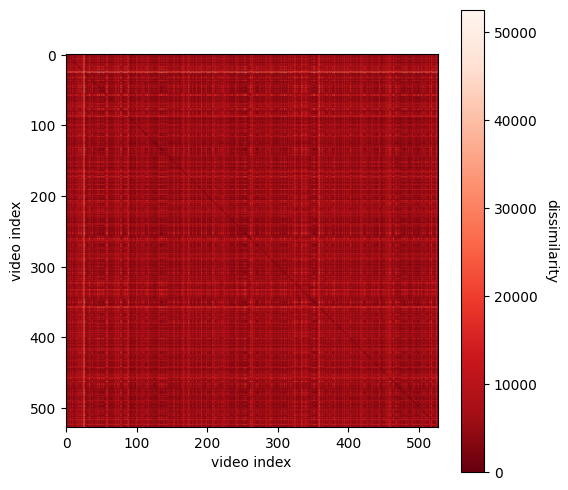

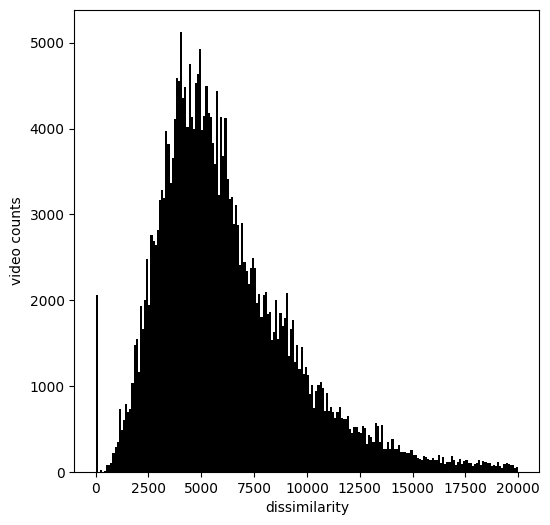

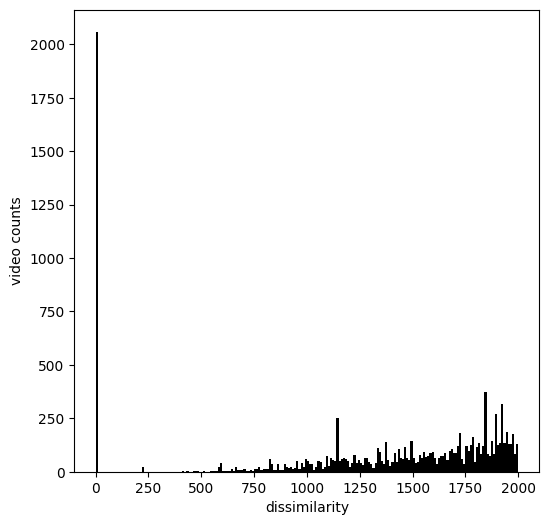

In [8]:
# plot dissimilarity matrix
fig, ax = plot_dissimilarity_matrix(dissimilarity)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-matrix_{thelabel}_{mapping[recording_folder]}.png"), dpi=300)

# plot histogrma with the distribution
fig, ax = plot_dissimilarity_hist(dissimilarity,bins=200, range=(0, 20000))
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-hist_{thelabel}_{mapping[recording_folder]}.png"), dpi=300)

# plot histogrma with the distribution zoomed in the range of interest
fig, ax = plot_dissimilarity_hist(dissimilarity,bins=200, range=(0, 2000))
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-hist_{thelabel}_{mapping[recording_folder]}_zoomed.png"), dpi=300)

### Gabor

In [21]:
recording_folder = all_recording_folders[1]
thelabel = 'Gabor'
dissimilarity, trials_df = ds.compute_dissimilarity_videos(recording=recording_folder, label=thelabel, check_edges_first=False)

Computing dissimilarity: 100%|██████████| 59/59 [00:03<00:00, 15.55it/s]


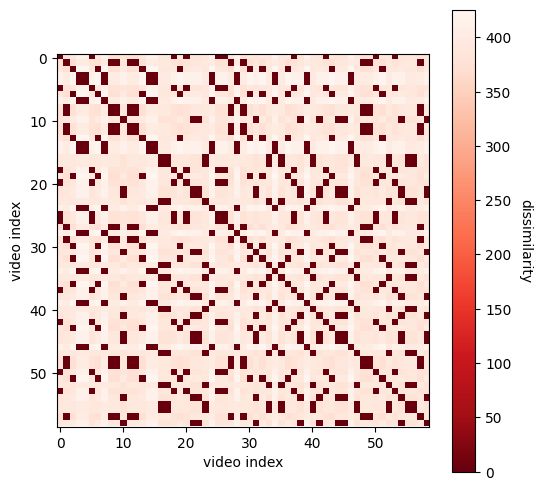

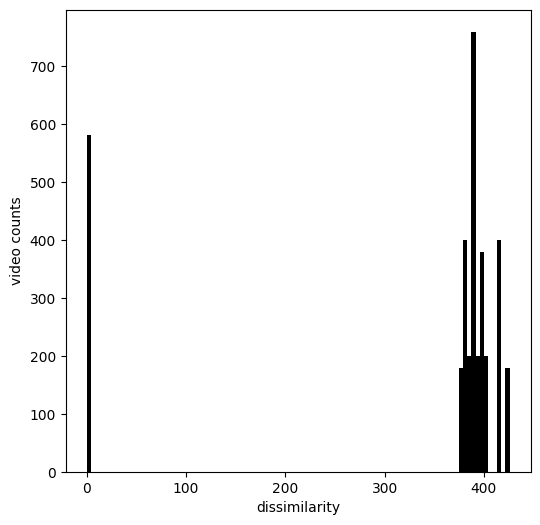

In [22]:
# plot dissimilarity matrix
fig, ax = plot_dissimilarity_matrix(dissimilarity)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-matrix_{thelabel}_rec-{mapping[recording_folder]}.png"), dpi=300)

# plot histogrma with the distribution
fig, ax = plot_dissimilarity_hist(dissimilarity,bins=100, range=None)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-hist_{thelabel}_rec-{mapping[recording_folder]}.png"), dpi=300)


### NaturalImages

In [23]:
recording_folder = all_recording_folders[1]
thelabel = 'NaturalImages'
dissimilarity, trials_df = ds.compute_dissimilarity_videos(recording=recording_folder, label=thelabel, check_edges_first=False)

Computing dissimilarity: 100%|██████████| 59/59 [00:04<00:00, 14.21it/s]


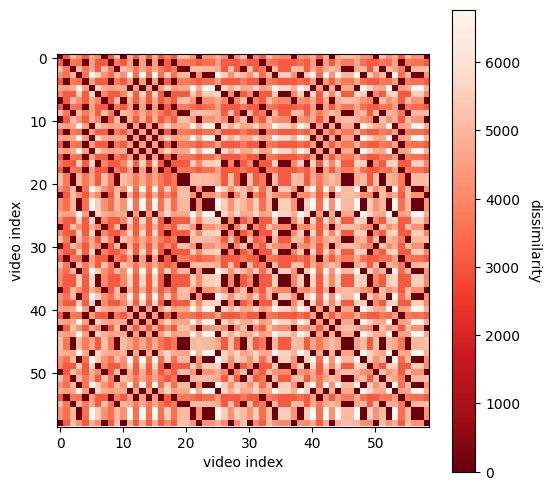

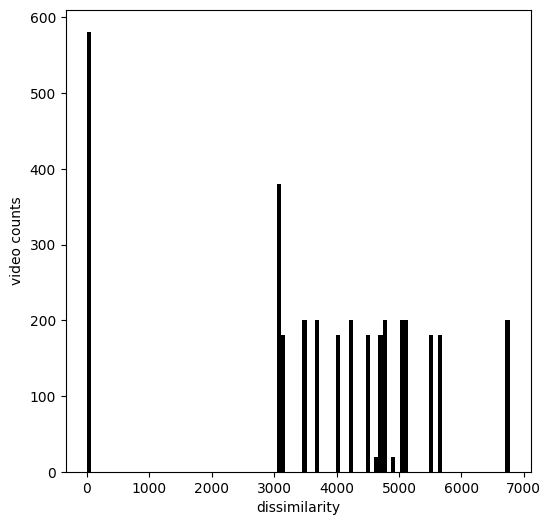

In [24]:
# plot dissimilarity matrix
fig, ax = plot_dissimilarity_matrix(dissimilarity)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-matrix_{thelabel}_{mapping[recording_folder]}.png"), dpi=300)

# plot histogrma with the distribution
fig, ax = plot_dissimilarity_hist(dissimilarity,bins=100, range=None)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-hist_{thelabel}_{mapping[recording_folder]}.png"), dpi=300)


### PinkNoise

In [25]:
recording_folder = all_recording_folders[1]
thelabel = 'PinkNoise'
dissimilarity, trials_df = ds.compute_dissimilarity_videos(recording=recording_folder, label=thelabel, check_edges_first=False)

Computing dissimilarity: 100%|██████████| 59/59 [00:04<00:00, 14.65it/s]


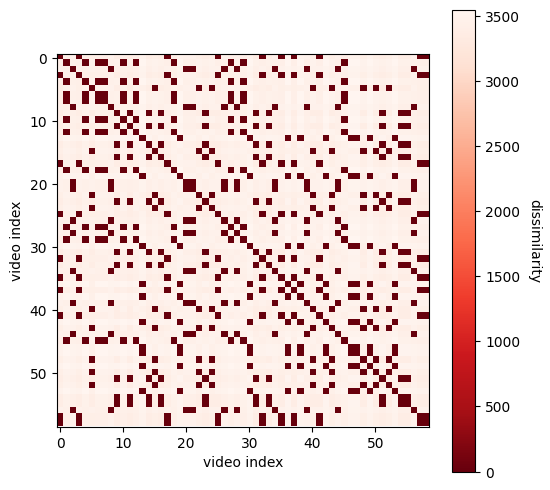

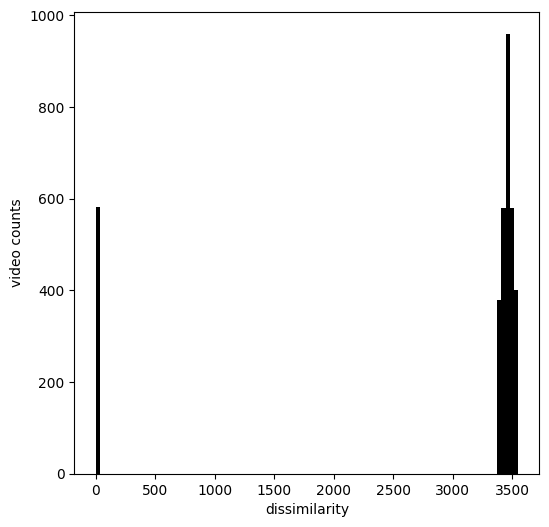

In [26]:
# plot dissimilarity matrix
fig, ax = plot_dissimilarity_matrix(dissimilarity)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-matrix_{thelabel}_{mapping[recording_folder][3:-3]}.png"), dpi=300)

# plot histogrma with the distribution
fig, ax = plot_dissimilarity_hist(dissimilarity,bins=100, range=None)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-hist_{thelabel}_{mapping[recording_folder][3:-3]}.png"), dpi=300)


### RandomDots

In [27]:
recording_folder = all_recording_folders[0]
thelabel = 'RandomDots'
dissimilarity, trials_df = ds.compute_dissimilarity_videos(recording=recording_folder, label=thelabel, check_edges_first=False)

Computing dissimilarity: 100%|██████████| 79/79 [00:05<00:00, 15.07it/s]


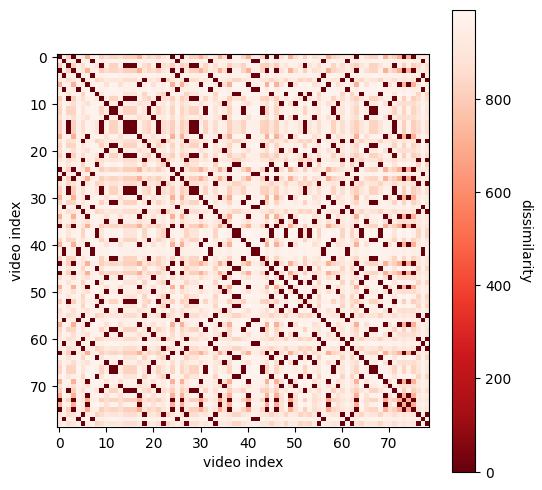

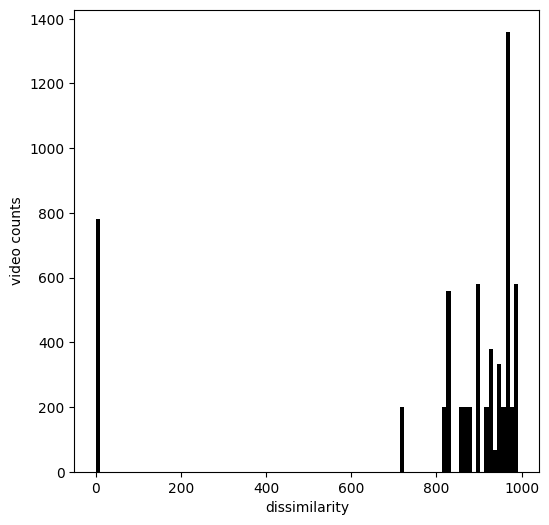

In [28]:
# plot dissimilarity matrix
fig, ax = plot_dissimilarity_matrix(dissimilarity)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-matrix_{thelabel}_{mapping[recording_folder][3:-3]}.png"), dpi=300)

# plot histogrma with the distribution
fig, ax = plot_dissimilarity_hist(dissimilarity,bins=100, range=None)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-hist_{thelabel}_{mapping[recording_folder][3:-3]}.png"), dpi=300)


### GaussianDot

In [29]:
recording_folder = all_recording_folders[0]
thelabel = 'GaussianDot'
dissimilarity, trials_df = ds.compute_dissimilarity_videos(recording=recording_folder, label=thelabel, check_edges_first=False)

Computing dissimilarity: 100%|██████████| 59/59 [00:04<00:00, 12.75it/s]


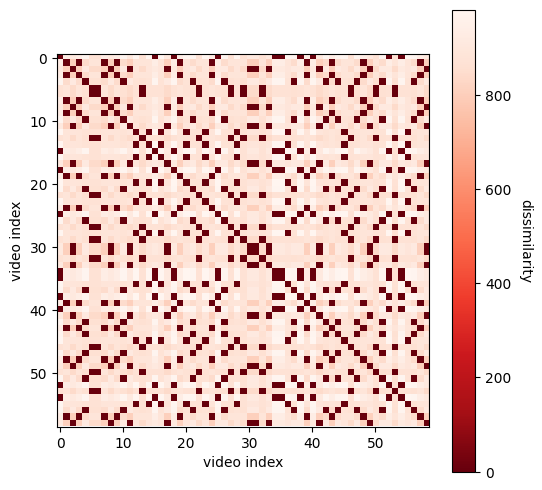

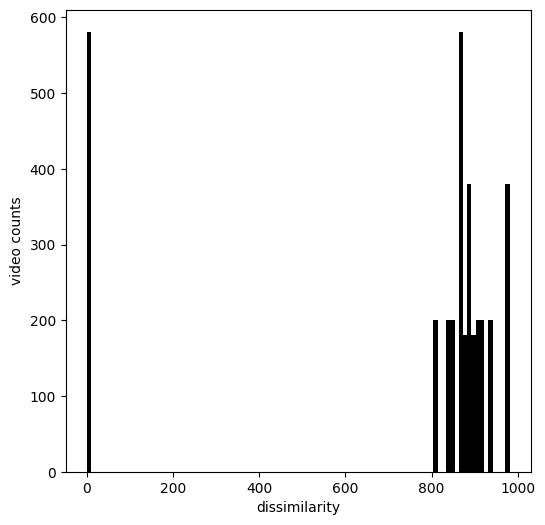

In [30]:
# plot dissimilarity matrix
fig, ax = plot_dissimilarity_matrix(dissimilarity)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-matrix_{thelabel}_{mapping[recording_folder][3:-3]}.png"), dpi=300)

# plot histogrma with the distribution
fig, ax = plot_dissimilarity_hist(dissimilarity,bins=100, range=None)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-hist_{thelabel}_{mapping[recording_folder][3:-3]}.png"), dpi=300)
